# Hand classifier
This model identifies the number of extended fingers based on a clear image of a human hand.  
The dataset contains a total of 300 images, which are split 70/15/15 to train, validation and test respectively.  

This model uses a CNN (Convolutional Neural Network) with data augmentation to classify the images.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

2026-04-27 10:36:17.552004: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow


In [2]:
from sklearn.model_selection import train_test_split
batch_size_n = 4
img_size = (224, 224)

train_dataset, validation_dataset = keras.utils.image_dataset_from_directory(
    'images/train',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    label_mode='categorical',
    validation_split=0.177, # ensures validation and test sets are equal size
    subset='both',
    shuffle=True,
    seed=123)

test_dataset = keras.utils.image_dataset_from_directory(
    'images/test',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    shuffle=False,
    label_mode='categorical')

Found 255 files belonging to 5 classes.
Using 210 files for training.
Using 45 files for validation.


I0000 00:00:1777275383.869311   28701 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 45 files belonging to 5 classes.


## Building the model
The CNN-model accepts a shape of (224, 224, 3) as its input. The input is then preprocessed with data augmentation.  
The convolutional part of the model consists of 3 layers with activation 'relu', with pooling between the layers.  
The output is flattened and fed to a layer with shape (128) and activation 'relu'.  
The final result has a Dropout layer applied to it.

In [3]:
from keras import Sequential
from keras import layers
from keras.optimizers import Adam
num_classes = 5

data_augmentation = Sequential([
    # preprocess
    layers.Rescaling(1./255),
    # augment
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    
    data_augmentation,

    # Convolution
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Output
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(optimizer=Adam(learning_rate = 0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [5]:
from keras.callbacks import EarlyStopping

history = model.fit(
    train_dataset,
    batch_size=4,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/50


2026-04-27 10:36:30.977027: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92000


53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.2429 - loss: 1.6521 - val_accuracy: 0.2000 - val_loss: 1.6091
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.2143 - loss: 1.6089 - val_accuracy: 0.1333 - val_loss: 1.6179
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.2190 - loss: 1.6087 - val_accuracy: 0.1778 - val_loss: 1.6113
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.2429 - loss: 1.6049 - val_accuracy: 0.2667 - val_loss: 1.6024
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.2095 - loss: 1.5967 - val_accuracy: 0.1333 - val_loss: 1.6018
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.2619 - loss: 1.5927 - val_accuracy: 0.2889 - val_loss: 1.5955
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.2714 - loss: 1.5829 - val_accuracy: 0.3333 - val_loss: 1.5549
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.2714 - loss: 1.5722 - val_accuracy: 0.2667 - val_loss: 1.

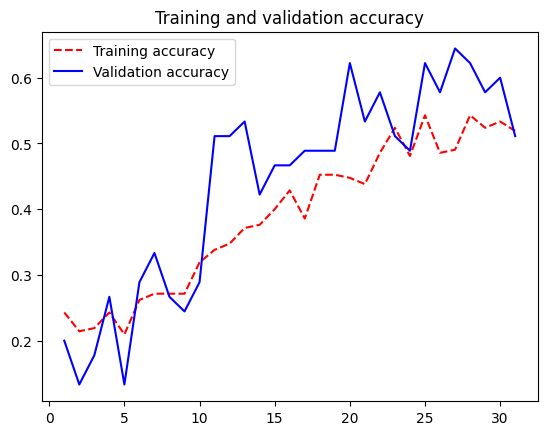

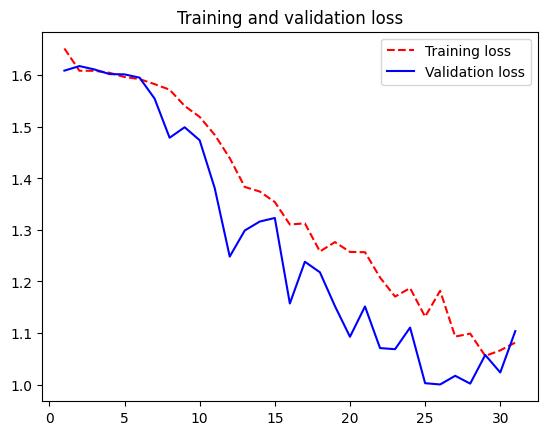

In [6]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [7]:
loss, acc = model.evaluate(test_dataset, verbose=0)
print(f"The model's test accuracy is {acc}")

The model's test accuracy is 0.6000000238418579


The convolutional model that was trained with these images from the beginning achieved an accuracy between 66-68%.
With 5 classes this means that the model has found some patterns and isn't just making wild guesses.  

Next, visualizing the model's predictions might make it easier to understand.

In [8]:
y_pred = model.predict(test_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(np.concatenate([y for x, y in test_dataset], axis=0), axis=1)

print(y_pred_classes)
print(y_true_classes)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 3 2 2 2 2 2 2 4 2 2 3 2 4 4 3 4
 4 4 4 4 2 4 4 4]
[0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 4
 4 4 4 4 4 4 4 4]


2026-04-27 10:37:47.040908: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
images = []
labels = []
class_names = ['1 finger', '2 fingers', '3 fingers', '4 fingers', '5 fingers']

for image_batch, label_batch in test_dataset:
    images.append(image_batch.numpy())
    labels.append(label_batch.numpy())

images = np.concatenate(images)
labels = np.concatenate(labels)

2026-04-27 10:37:47.132331: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [10]:
def show_example_images_and_predictions(predicted_labels):
    plt.figure(figsize=(15, 8))
    
    for i in range(20):
        plt.subplot(4, 5, i + 1)
    
        plt.imshow(images[i].astype("uint8"))
    
        true_label = y_true_classes[i]
        pred_label = predicted_labels[i]
    
        color = "green" if true_label == pred_label else "red"
    
        plt.title(
            f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}",
            color=color
        )
    
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

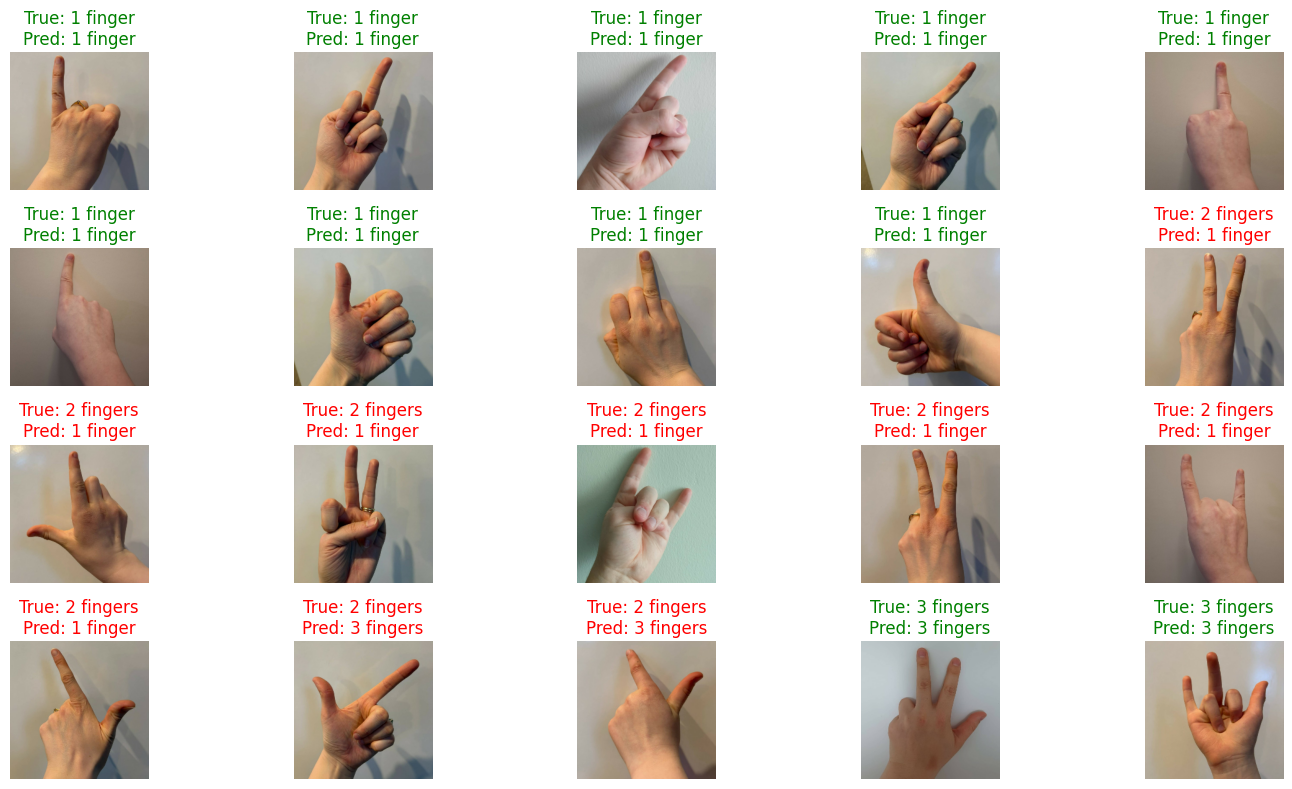

In [11]:
show_example_images_and_predictions(y_pred_classes)